In [1]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def covariance_to_correlation(covariance):
    D = np.diag(1 / np.sqrt(np.diag(covariance)))
    return D @ covariance @ D  # correlation matrix

In [3]:
prefix = "/gpfs/cfel/user/tjlane/mpro/mprodata/covariance/covariance_matrices/"

dataset_paths = {
    "DESY"    : prefix + "cov_xtal_ensemble.npy",
    "Diamond" : prefix + "cov_dmnd_ensemble.npy",
    "DESRES"  : prefix + "desres_sim.npy",
    "RIKEN"   : prefix + "riken_sim.npy",
    "GaMD"   : prefix + "amaro_sim.npy",
}

datasets = {}

In [4]:
for dataset_name, dataset_path in dataset_paths.items():
    dataset = np.load(dataset_path)
    print(dataset_name, dataset.shape)
    datasets[dataset_name] = dataset

DESY (303, 303)
Diamond (303, 303)
DESRES (303, 303)
RIKEN (303, 303)
GaMD (303, 303)


In [9]:
distance_matrix = np.zeros([len(datasets),] * 2)

for i, (dataset1_name, dataset1) in enumerate(datasets.items()):
    for j, (dataset2_name, dataset2) in enumerate(datasets.items()):
        
        corr1 = covariance_to_correlation(dataset1)
        corr2 = covariance_to_correlation(dataset2)

        dist = np.linalg.norm(corr1 - corr2, ord="fro")

        distance_matrix[i,j] = dist
        
        print(dataset1_name, dataset2_name, dist)

DESY DESY 0.0
DESY Diamond 89.94735115527536
DESY DESRES 79.84919728659517
DESY RIKEN 103.39380740954738
DESY GaMD 78.70415335409673
Diamond DESY 89.94735115527536
Diamond Diamond 0.0
Diamond DESRES 57.527517448147954
Diamond RIKEN 76.27652941363287
Diamond GaMD 63.32381961010664
DESRES DESY 79.84919728659517
DESRES Diamond 57.527517448147954
DESRES DESRES 0.0
DESRES RIKEN 59.007739950178404
DESRES GaMD 33.87205428399342
RIKEN DESY 103.39380740954738
RIKEN Diamond 76.27652941363287
RIKEN DESRES 59.007739950178404
RIKEN RIKEN 0.0
RIKEN GaMD 59.98577266185889
GaMD DESY 78.70415335409673
GaMD Diamond 63.32381961010664
GaMD DESRES 33.87205428399342
GaMD RIKEN 59.98577266185889
GaMD GaMD 0.0


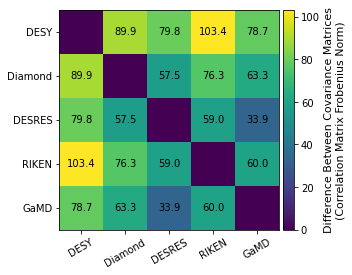

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(distance_matrix, cmap="viridis")

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(datasets.keys(), rotation=30, ha="center")
ax.set_yticklabels(datasets.keys())

for i in range(distance_matrix.shape[0]):
    for j in range(distance_matrix.shape[1]):
        if i != j:
            ax.text(j, i, f"{distance_matrix[i, j]:.1f}", ha="center", va="center", color="black")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Difference Between Covariance Matrices\n(Correlation Matrix Frobenius Norm)", fontsize=11)

plt.tight_layout()
plt.savefig("./figures/correlation-matrix-frobenius-norm.pdf")
plt.show()